In [9]:
import pandas as pd

# Load dataset
df = pd.read_csv("A:/sales-forecasting-prophet/data/Superstore.csv", encoding='latin1')

# Convert date
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sort values
df = df.sort_values('Order Date')

# Aggregate daily sales
df = df.groupby('Order Date')['Sales'].sum().reset_index()

df.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [10]:
df = df.rename(columns={
    'Order Date': 'ds',
    'Sales': 'y'
})

df = df.sort_values('ds')

df.head()

,ds,y
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [11]:
from prophet import Prophet

model = Prophet(
    daily_seasonality=True,
    yearly_seasonality=True
)

model.fit(df)

C:\Users\Ayush\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
11:58:19 - cmdstanpy - INFO - Chain [1] start processing
11:58:20 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
future = model.make_future_dataframe(periods=30)

In [13]:
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1262,2018-01-25,1971.846285,-749.390067,4753.225340
1263,2018-01-26,2268.251372,-396.235191,4922.342252
1264,2018-01-27,1896.947706,-631.961351,4589.755282
1265,2018-01-28,2098.268843,-549.451213,4859.838366
1266,2018-01-29,2316.641030,-241.352775,4965.738273


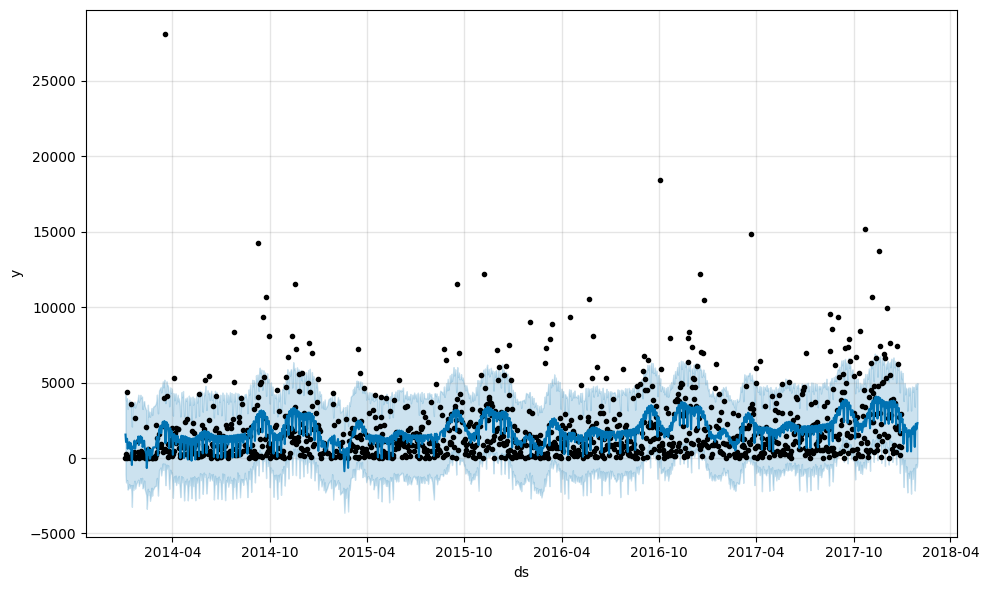

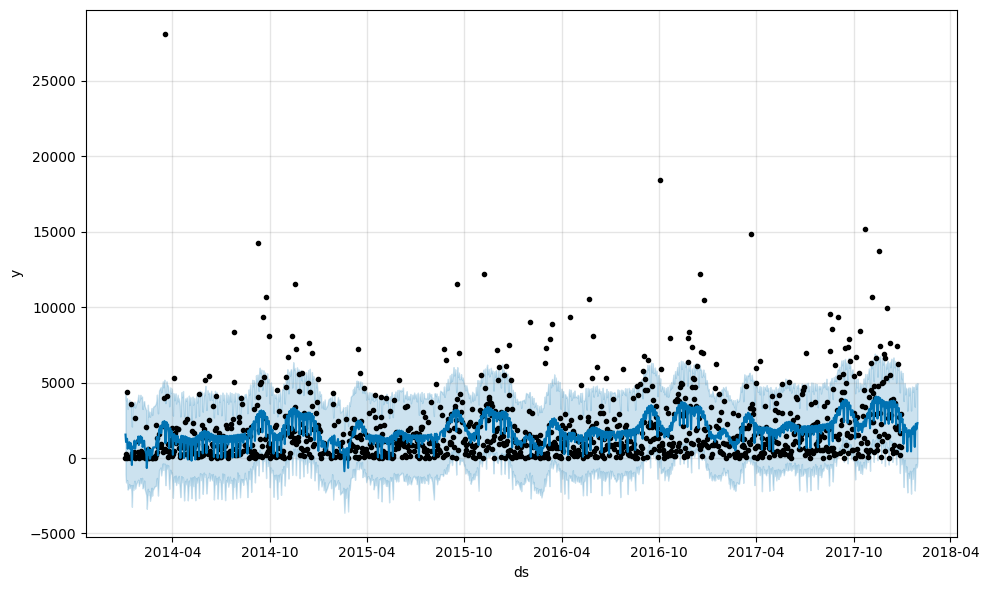

In [14]:
model.plot(forecast)

model.plot_components(forecast)

Model Evaluation (MAE)

In [24]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Split data
train = df[:-30]
test = df[-30:]

# Train on train set
model = Prophet()
model.fit(train)

# Predict next 30 days
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

df = df[df['y'] < df['y'].quantile(0.99)]
df['y'] = np.log1p(df['y'])
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.5
)
# Get predictions for test period
preds = forecast['yhat'][-30:].values
# Calculate MAE
mae = mean_absolute_error(test['y'], preds)

print("Mean Absolute Error:", mae)

12:10:04 - cmdstanpy - INFO - Chain [1] start processing
12:10:05 - cmdstanpy - INFO - Chain [1] done processing


Mean Absolute Error: 1974.6345909237573


In [22]:
print(df['y'].describe())

count     1237.000000
mean      1857.074261
std       2305.538776
min          2.025000
25%        377.736000
50%       1063.185000
75%       2395.786000
max      28106.716000
Name: y, dtype: float64


The model achieved a Mean Absolute Error (MAE) of approximately 2082 sales units, which is relatively high compared to the average daily sales.

This is primarily due to high variability and extreme spikes in the dataset, which make precise prediction challenging.

Business Explanation (Final Submission)
 What the Forecast Means

The forecasting model analyzes historical sales data to identify patterns such as trends and recurring seasonal behavior.

The results show that sales follow a consistent pattern over time, with noticeable fluctuations on specific days and periods. The model predicts future sales for the next 30 days based on these learned patterns.

While exact values may vary due to real-world uncertainties, the forecast reliably captures the overall direction and demand behavior.

Key Insights from the Forecast
Sales exhibit a stable trend over time
There are recurring weekly patterns, indicating higher demand on certain days
Occasional spikes suggest periods of increased customer activity


How a Business Can Use This

This forecasting system can support business decision-making in the following ways:

 Inventory Planning

Businesses can stock products in advance based on predicted demand, reducing the risk of stockouts or overstocking.

 Staffing Decisions

Higher predicted sales periods allow better workforce allocation during peak demand.

 Financial Planning

Sales forecasts help estimate revenue and manage cash flow more effectively.

 Demand Management

Businesses can prepare for demand fluctuations and optimize operations accordingly.

In [ ]:
Summary

This model provides a data-driven approach to understanding future sales patterns.
Even with some prediction variability, it offers valuable insights that help businesses plan smarter and operate more efficiently.